<a href="https://colab.research.google.com/github/melia1702/Pertemuan-keduabelas/blob/main/TUGAS_MG_12_FITUR_LOKAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload semua gambar (contoh nama: buku1.jpg, buku2.jpg, mug1.jpg, ...)


Saving gambar remote.jpg to gambar remote (2).jpg
Saving gambar mainan.jpg to gambar mainan (2).jpg
Saving gambar botol.jpg to gambar botol (2).jpg
Saving gambar mug.jpg to gambar mug (2).jpg
Saving gambar buku.jpg to gambar buku (3).jpg
Jumlah gambar: 5

Ekstraksi fitur SIFT...
Ekstraksi fitur ORB...

=== STATISTIK ===
SIFT avg keypoints: 353.0
ORB avg keypoints: 402.6
SIFT avg time: 0.7827682018280029
ORB avg time: 0.015272283554077148


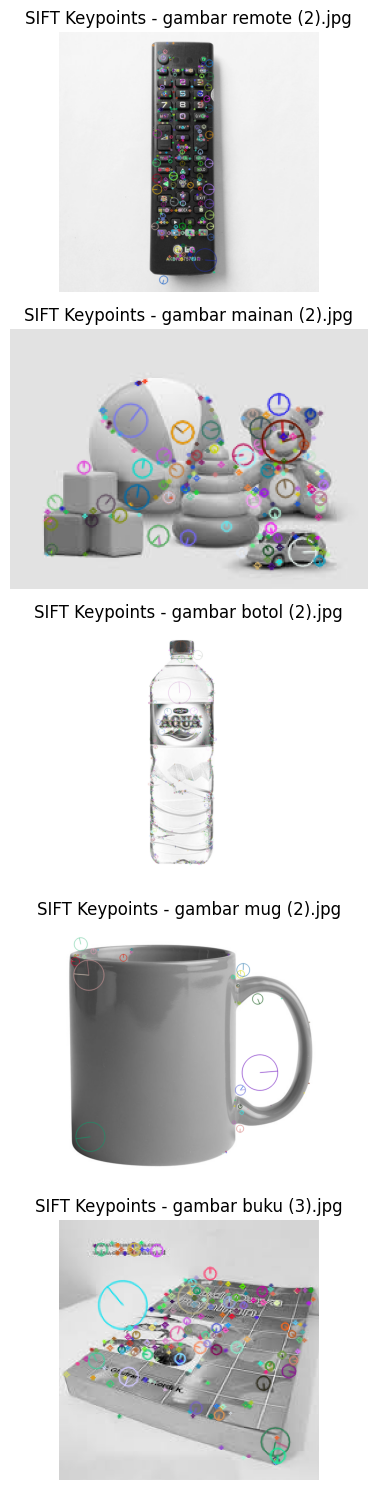

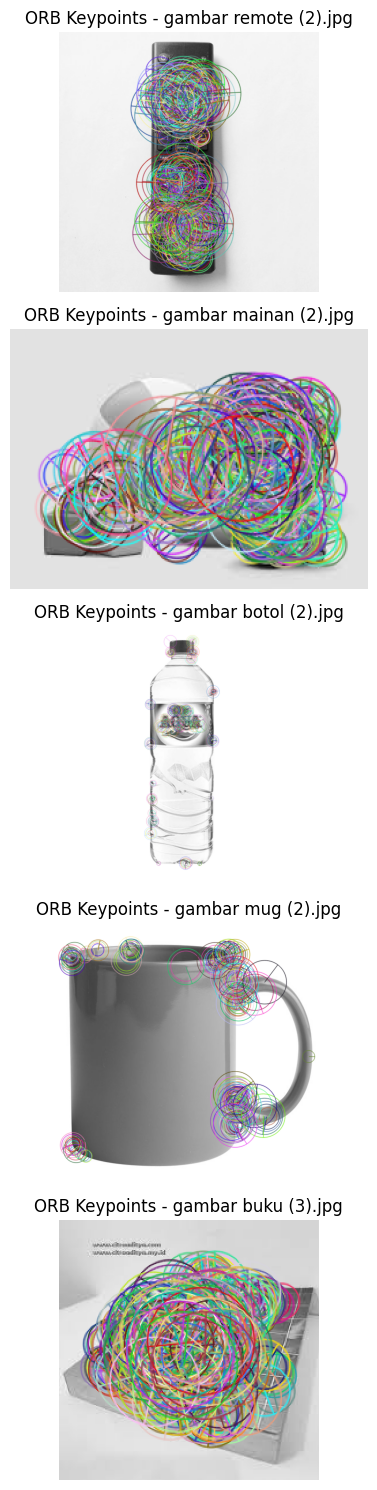


Visualisasi matching (gambar 0 vs 1)...


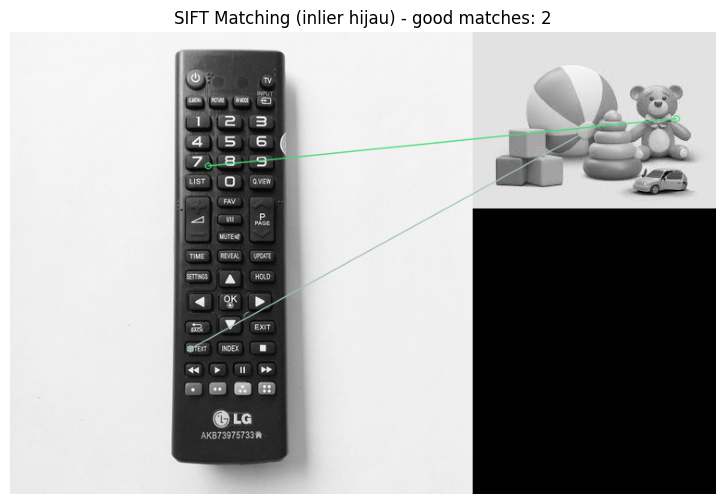


Menghitung Precision-Recall...


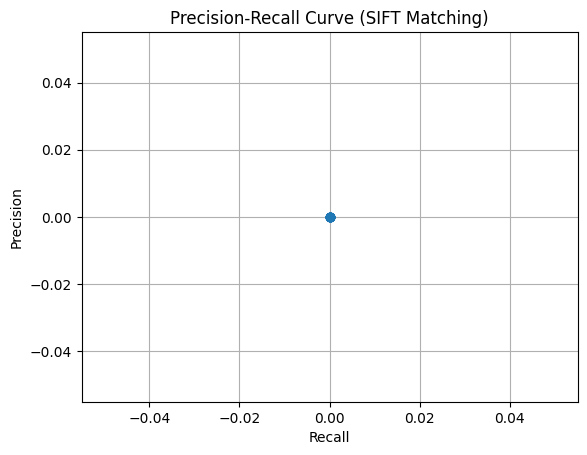


BoVW + SVM...
k=10 -> accuracy=1.000
k=20 -> accuracy=1.000
k=50 -> accuracy=1.000


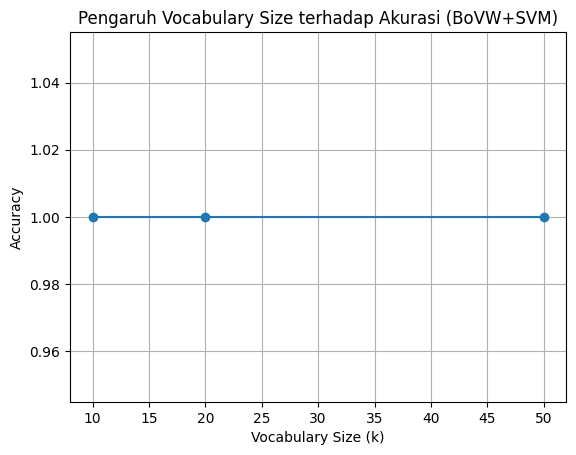


Confusion Matrix (k terbaik):
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]

Classification Report:
                  precision    recall  f1-score   support

 gambar botol ()       1.00      1.00      1.00         1
  gambar buku ()       1.00      1.00      1.00         1
gambar mainan ()       1.00      1.00      1.00         1
   gambar mug ()       1.00      1.00      1.00         1
gambar remote ()       1.00      1.00      1.00         1

        accuracy                           1.00         5
       macro avg       1.00      1.00      1.00         5
    weighted avg       1.00      1.00      1.00         5


PCA evaluasi...
PCA 16 -> acc=1.000
PCA 32 -> acc=1.000
PCA 64 -> acc=1.000
PCA 128 -> acc=1.000


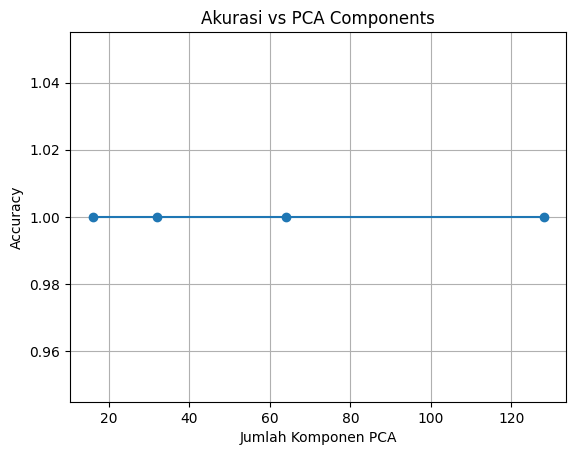

In [6]:
# =========================================
# SISTEM PENC0COKAN OBJEK (UPLOAD + VISUALISASI)
# =========================================
# Jalankan di Google Colab

import cv2
import numpy as np
import time
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from google.colab import files

# =========================================
# UPLOAD GAMBAR
# =========================================
print("Upload semua gambar (contoh nama: buku1.jpg, buku2.jpg, mug1.jpg, ...)")
uploaded = files.upload()

images = []
labels = []
filenames = []

for filename in uploaded.keys():
    img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    images.append(img)
    filenames.append(filename)
    # label = huruf sebelum angka (buku1.jpg -> buku)
    label = ''.join([c for c in filename if not c.isdigit()]).split('.')[0]
    labels.append(label)

print("Jumlah gambar:", len(images))

# =========================================
# FEATURE EXTRACTION
# =========================================

def get_detector(method):
    if method == "SIFT":
        return cv2.SIFT_create()
    elif method == "ORB":
        return cv2.ORB_create()
    else:
        raise ValueError("Method tidak didukung")


def extract_features(method, images):
    detector = get_detector(method)
    descriptors_list = []
    keypoints_list = []
    keypoints_count = []
    times = []

    for img in images:
        start = time.time()
        kp, des = detector.detectAndCompute(img, None)
        end = time.time()

        keypoints_list.append(kp)
        keypoints_count.append(0 if kp is None else len(kp))
        times.append(end - start)
        if des is None:
            # agar tidak error saat stacking
            if method == "ORB":
                des = np.zeros((1, 32), dtype=np.uint8)
            else:
                des = np.zeros((1, 128), dtype=np.float32)
        descriptors_list.append(des)

    return descriptors_list, keypoints_list, keypoints_count, times

# =========================================
# VISUALISASI KEYPOINTS
# =========================================

def show_keypoints(images, keypoints_list, method, max_show=5):
    n = min(len(images), max_show)
    plt.figure(figsize=(12, 3*n))
    for i in range(n):
        img_kp = cv2.drawKeypoints(images[i], keypoints_list[i], None,
                                   flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        plt.subplot(n, 1, i+1)
        plt.imshow(img_kp, cmap='gray')
        plt.title(f"{method} Keypoints - {filenames[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# =========================================
# FEATURE MATCHING + RATIO TEST
# =========================================

def match_features(des1, des2, method="SIFT"):
    if method == "SIFT":
        bf = cv2.BFMatcher(cv2.NORM_L2)
    else:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)
    return good

# =========================================
# VISUALISASI MATCHING + INLIER/OUTLIER (RANSAC)
# =========================================

def draw_matches_with_ransac(img1, kp1, img2, kp2, matches):
    if len(matches) < 10:
        vis = cv2.drawMatches(img1, kp1, img2, kp2, matches, None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        return vis, None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matchesMask = mask.ravel().tolist() if mask is not None else None

    draw_params = dict(matchColor=(0,255,0),
                       singlePointColor=None,
                       matchesMask=matchesMask,
                       flags=2)

    vis = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, **draw_params)
    return vis, matchesMask

# =========================================
# PRECISION-RECALL (BERDASAR THRESHOLD JUMLAH MATCH)
# =========================================

def compute_pr_curve(descriptors_list, keypoints_list, labels, method="SIFT"):
    thresholds = list(range(5, 60, 5))
    precision = []
    recall = []

    n = len(descriptors_list)
    for th in thresholds:
        tp = fp = fn = 0
        for i in range(n):
            for j in range(i+1, n):
                good = match_features(descriptors_list[i], descriptors_list[j], method)
                same = (labels[i] == labels[j])
                pred_same = (len(good) >= th)
                if pred_same and same:
                    tp += 1
                elif pred_same and not same:
                    fp += 1
                elif (not pred_same) and same:
                    fn += 1
        prec = tp / (tp + fp + 1e-9)
        rec = tp / (tp + fn + 1e-9)
        precision.append(prec)
        recall.append(rec)

    return thresholds, precision, recall

# =========================================
# BOVW
# =========================================

def build_bovw(descriptors_list, k=20):
    all_des = np.vstack(descriptors_list)
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(all_des)
    return kmeans


def build_histogram(descriptors_list, kmeans):
    histograms = []
    for des in descriptors_list:
        words = kmeans.predict(des)
        hist, _ = np.histogram(words, bins=np.arange(kmeans.n_clusters+1))
        hist = hist.astype(float) / (np.sum(hist) + 1e-9)
        histograms.append(hist)
    return np.array(histograms)

# =========================================
# MAIN PIPELINE
# =========================================

print("\nEkstraksi fitur SIFT...")
sift_des, sift_kp, kp_sift, time_sift = extract_features("SIFT", images)

print("Ekstraksi fitur ORB...")
orb_des, orb_kp, kp_orb, time_orb = extract_features("ORB", images)

print("\n=== STATISTIK ===")
print("SIFT avg keypoints:", np.mean(kp_sift))
print("ORB avg keypoints:", np.mean(kp_orb))
print("SIFT avg time:", np.mean(time_sift))
print("ORB avg time:", np.mean(time_orb))

# =========================================
# VISUALISASI KEYPOINTS
# =========================================
show_keypoints(images, sift_kp, "SIFT")
show_keypoints(images, orb_kp, "ORB")

# =========================================
# MATCHING VISUALISASI (gambar 0 vs 1)
# =========================================
print("\nVisualisasi matching (gambar 0 vs 1)...")
if len(images) >= 2:
    good = match_features(sift_des[0], sift_des[1], "SIFT")
    vis, mask = draw_matches_with_ransac(images[0], sift_kp[0], images[1], sift_kp[1], good)

    plt.figure(figsize=(12,6))
    plt.imshow(vis, cmap='gray')
    plt.title(f"SIFT Matching (inlier hijau) - good matches: {len(good)}")
    plt.axis('off')
    plt.show()

# =========================================
# PRECISION-RECALL CURVE
# =========================================
print("\nMenghitung Precision-Recall...")
th, prec, rec = compute_pr_curve(sift_des, sift_kp, labels, "SIFT")

plt.figure()
plt.plot(rec, prec, marker='o')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (SIFT Matching)')
plt.grid()
plt.show()

# =========================================
# BOVW + KLASIFIKASI (variasi k)
# =========================================
print("\nBoVW + SVM...")
ks = [10, 20, 50]
accs = []
for k in ks:
    kmeans = build_bovw(sift_des, k=k)
    hist = build_histogram(sift_des, kmeans)
    clf = SVC()
    clf.fit(hist, labels)
    pred = clf.predict(hist)
    acc = np.mean(np.array(pred) == np.array(labels))
    accs.append(acc)
    print(f"k={k} -> accuracy={acc:.3f}")

plt.figure()
plt.plot(ks, accs, marker='o')
plt.xlabel('Vocabulary Size (k)')
plt.ylabel('Accuracy')
plt.title('Pengaruh Vocabulary Size terhadap Akurasi (BoVW+SVM)')
plt.grid()
plt.show()

# Confusion Matrix untuk k terbaik
best_k = ks[int(np.argmax(accs))]
kmeans = build_bovw(sift_des, k=best_k)
hist = build_histogram(sift_des, kmeans)
clf = SVC()
clf.fit(hist, labels)
pred = clf.predict(hist)

print("\nConfusion Matrix (k terbaik):")
print(confusion_matrix(labels, pred))
print("\nClassification Report:")
print(classification_report(labels, pred))

# =========================================
# PCA + EVALUASI DIMENSI
# =========================================
print("\nPCA evaluasi...")
all_des = np.vstack(sift_des)
comps = [16, 32, 64, 128]
acc_pca = []

for c in comps:
    pca = PCA(n_components=min(c, all_des.shape[1]))
    red = pca.fit_transform(all_des)
    # bangun ulang histogram sederhana (kuantisasi ulang via kmeans kecil)
    kmeans = KMeans(n_clusters=20, n_init=10, random_state=42)
    kmeans.fit(red)

    # bagi kembali per gambar
    hists = []
    idx = 0
    for des in sift_des:
        n = des.shape[0]
        part = red[idx:idx+n]
        idx += n
        words = kmeans.predict(part)
        hist, _ = np.histogram(words, bins=np.arange(21))
        hist = hist.astype(float) / (np.sum(hist) + 1e-9)
        hists.append(hist)

    hists = np.array(hists)
    clf = SVC()
    clf.fit(hists, labels)
    pred = clf.predict(hists)
    acc = np.mean(np.array(pred) == np.array(labels))
    acc_pca.append(acc)
    print(f"PCA {c} -> acc={acc:.3f}")

plt.figure()
plt.plot(comps, acc_pca, marker='o')
plt.xlabel('Jumlah Komponen PCA')
plt.ylabel('Accuracy')
plt.title('Akurasi vs PCA Components')
plt.grid()
plt.show()
